In [4]:
# !unzip archive.zip

In [5]:
from torchvision import datasets, transforms

In [ ]:
train_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_data_transform = transforms.Compose([
      transforms.Resize((128, 128)),
      transforms.ToTensor(),
      transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [58]:
train = datasets.ImageFolder("Training", transform=train_transforms)
test = datasets.ImageFolder("Training", transform=test_data_transform)

In [139]:
len(train), len(test)

(5600, 5600)

In [8]:
train.classes

['glioma', 'meningioma', 'notumor', 'pituitary']

In [9]:
from torch.utils.data import DataLoader

In [10]:
train_data_loader = DataLoader(train, batch_size=32, shuffle=True)
test_data_loader = DataLoader(test, batch_size=32, shuffle=True)

In [12]:
images, labels = next(iter(train_data_loader))

print("Batch shape:", images.shape)   # e.g. torch.Size([128, 3, 224, 224])
print("Labels shape:", labels.shape)  # e.g. torch.Size([128])
print("Labels:", labels)

Batch shape: torch.Size([32, 3, 128, 128])
Labels shape: torch.Size([32])
Labels: tensor([1, 0, 1, 1, 2, 0, 1, 0, 2, 3, 2, 0, 1, 1, 2, 2, 2, 3, 1, 3, 0, 1, 1, 2,
        0, 0, 3, 0, 0, 3, 2, 1])


In [13]:
import torch

In [14]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [15]:
from torchvision import models

In [16]:
model = models.vgg16()

In [17]:
model

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [18]:
model.features

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (17): Conv2d(256, 512, kernel_si

In [19]:
model.classifier

Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=4096, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=4096, out_features=1000, bias=True)
)

In [20]:
for params in model.features:
    params.requires_grad = False

In [21]:
import torch.nn as nn

In [22]:
model.classifier = nn.Sequential(
    nn.Linear(in_features=25088, out_features=1024, bias=True),
    nn.ReLU(),
    nn.Dropout(p=0.5),
    nn.Linear(in_features=1024, out_features=4, bias=True)
)

In [24]:
model

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [25]:
model = model.to(device)

In [26]:
import torch

In [28]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.classifier.parameters(), lr=1e-4)

In [29]:
for epoch in range(10):

  total_loss = 0
  for img, label in train_data_loader:
    img, label = img.to(device), label.to(device)

    optimizer.zero_grad()

    output = model(img)
    loss = criterion(output, label)
    loss.backward()
    optimizer.step()

    total_loss += loss.item()
  avg_loss = total_loss / len(train_data_loader)
  print(f"Epoch: {epoch+1}, Loss: {avg_loss}")

Epoch: 1, Loss: 1.1785100752966744
Epoch: 2, Loss: 0.9733693817683629
Epoch: 3, Loss: 0.8674553663390023
Epoch: 4, Loss: 0.7907963088580541
Epoch: 5, Loss: 0.7427763276440756
Epoch: 6, Loss: 0.710242907830647
Epoch: 7, Loss: 0.6709750291279384
Epoch: 8, Loss: 0.6557306528091431
Epoch: 9, Loss: 0.6462176135608129
Epoch: 10, Loss: 0.6060574318681444


In [30]:
model.eval()

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [31]:
all_pred_lebal = []
act_label = []

In [43]:
with torch.no_grad():
  for img, label in test_data_loader:
    img, label = img.to(device), label.to(device)
    output = model(img)
    _, predict = torch.max(output, 1)

    all_pred_lebal.extend(predict.cpu().numpy())
    act_label.extend(label.cpu().numpy())

In [53]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [45]:
accuracy_score(act_label, all_pred_lebal)

0.6019642857142857

In [55]:
print("/n", classification_report(act_label, all_pred_lebal))

/n               precision    recall  f1-score   support

           0       0.65      0.55      0.59      1400
           1       0.70      0.18      0.29      1400
           2       0.64      0.85      0.73      1400
           3       0.53      0.82      0.64      1400

    accuracy                           0.60      5600
   macro avg       0.63      0.60      0.56      5600
weighted avg       0.63      0.60      0.56      5600



In [48]:
import seaborn

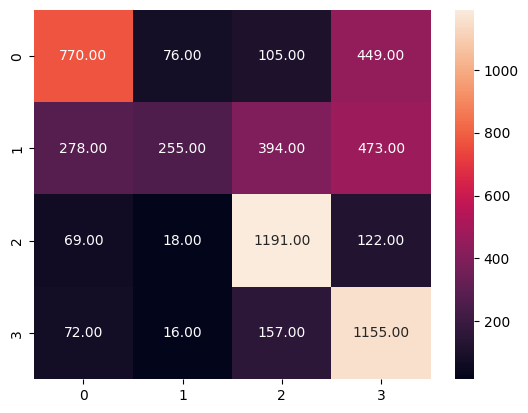

In [52]:
seaborn.heatmap(confusion_matrix(act_label, all_pred_lebal), annot=True, fmt=".2f");

In [98]:
def predict_tumor(image):
  output = model(image.unsqueeze(0).to(device))
  prob = torch.softmax(output, dim=1)
  _, label = torch.max(prob, dim=1)
  print(f"Confidance Score: {_}, Class: {test.classes[label.item()]}")

In [108]:
predict_tumor(test[2][0])

Confidance Score: tensor([0.4956], device='cuda:0', grad_fn=<MaxBackward0>), Class: pituitary


In [114]:
model_vgg = models.vgg19()

In [115]:
model_vgg

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padd

In [130]:
model_vgg.classifier = nn.Sequential(
    nn.Linear(in_features=25088, out_features=1024, bias=True),
    nn.ReLU(),
    nn.Dropout(p=0.5),
    nn.Linear(in_features=1024, out_features=4, bias=True)
)

In [131]:
model_vgg.to(device)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padd

In [132]:
for params in model.features:
    params.requires_grad = False

In [133]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_vgg.classifier.parameters(), lr=1e-4)

In [134]:
for epoch in range(10):

  total_loss = 0
  for img, label in train_data_loader:
    img, label = img.to(device), label.to(device)

    optimizer.zero_grad()

    output = model_vgg(img)
    loss = criterion(output, label)
    loss.backward()
    optimizer.step()

    total_loss += loss.item()
  avg_loss = total_loss / len(train_data_loader)
  print(f"Epoch: {epoch+1}, Loss: {avg_loss}")

Epoch: 1, Loss: 1.277034055846078
Epoch: 2, Loss: 1.076775276660919
Epoch: 3, Loss: 0.9553213776860918
Epoch: 4, Loss: 0.8772742264611381
Epoch: 5, Loss: 0.8119447130816323
Epoch: 6, Loss: 0.7621050459997994
Epoch: 7, Loss: 0.7262747115748269
Epoch: 8, Loss: 0.713588616166796
Epoch: 9, Loss: 0.6757950326374599
Epoch: 10, Loss: 0.6568833647455488


In [136]:
model_vgg.eval()

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padd

In [137]:
all_pred_lebal = []
act_label = []

with torch.no_grad():
  for img, label in test_data_loader:
    img, label = img.to(device), label.to(device)
    output = model_vgg(img)
    _, predict = torch.max(output, 1)

    all_pred_lebal.extend(predict.cpu().numpy())
    act_label.extend(label.cpu().numpy())

In [138]:
print("/n", classification_report(act_label, all_pred_lebal))

/n               precision    recall  f1-score   support

           0       0.64      0.52      0.57      1400
           1       0.60      0.15      0.24      1400
           2       0.48      0.89      0.62      1400
           3       0.54      0.58      0.56      1400

    accuracy                           0.53      5600
   macro avg       0.56      0.53      0.50      5600
weighted avg       0.56      0.53      0.50      5600

